# EDA - Dataset histórico (2019) y dataset espacial

Variables de datasets a considerar:

**Dataset histórico:**

- **df_500k**: 500.000 primeras muestras del conjunto de datos original.

- **df_500k_mod**: dataset original modificado con nuevas variables y procesamiento.

**Dataset espacial:**

- **df_spatial**: dataset completo original.

- **df_sensors_geolocated**: dataset con los sensores que coinciden con las ubicaciones del dataset espacial. Se guardan ubicaciones únicas, sin duplicados. Usado para generar el mapa de visualización.


In [1]:
import pandas as pd
import os

data_folder = os.environ.get("DATA_FOLDER_PATH_IPYNB", "../../data/")
csv_name = os.environ.get("CSV_2019_RAW_NAME", "On-street_Car_Parking_Sensor_Data_-_2019.csv")
csv_path = os.path.join(data_folder, csv_name)

df_500k = pd.read_csv(csv_path, nrows=500000, low_memory=False) # low_memory=False to avoid dtype inference issues with mixed types
df_500k.info()
display(df_500k.head())
df_500k.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DeviceId          500000 non-null  int64  
 1   ArrivalTime       500000 non-null  str    
 2   DepartureTime     500000 non-null  str    
 3   DurationMinutes   500000 non-null  str    
 4   StreetMarker      500000 non-null  str    
 5   SignPlateID       328141 non-null  float64
 6   Sign              328141 non-null  str    
 7   AreaName          500000 non-null  str    
 8   StreetId          500000 non-null  int64  
 9   StreetName        500000 non-null  str    
 10  BetweenStreet1ID  500000 non-null  int64  
 11  BetweenStreet1    500000 non-null  str    
 12  BetweenStreet2ID  500000 non-null  int64  
 13  BetweenStreet2    500000 non-null  str    
 14  SideOfStreet      500000 non-null  int64  
 15  SideOfStreetCode  500000 non-null  str    
 16  SideName          500000 non-nu

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,23915,11/03/2019 03:00:56 AM,11/03/2019 03:07:26 AM,7,2374N,NaN,NaN,Windsor,123,BOURKE STREET,1221,RUSSELL STREET,647,EXHIBITION STREET,3,N,North,1753,False,False
1,23914,04/16/2019 02:14:47 PM,04/16/2019 02:15:23 PM,1,1896N,287.0,1P MTR M-SAT 7:30-18:30,Twin Towers,528,COLLINS STREET,647,EXHIBITION STREET,1288,SPRING STREET,3,N,North,1532,False,False
2,23913,09/29/2019 01:08:22 AM,09/29/2019 01:31:41 AM,23,1581S,NaN,NaN,Banks,670,FLINDERS STREET,1171,QUEEN STREET,627,ELIZABETH STREET,4,S,South,1399,False,False
3,23915,06/05/2019 06:59:17 PM,06/05/2019 06:59:24 PM,0,2374N,508.0,2P MTR M-SAT 18.30 - 20.30,Windsor,123,BOURKE STREET,1221,RUSSELL STREET,647,EXHIBITION STREET,3,N,North,1753,False,False
4,23915,04/01/2019 07:03:41 AM,04/01/2019 07:14:12 AM,11,2374N,NaN,NaN,Windsor,123,BOURKE STREET,1221,RUSSELL STREET,647,EXHIBITION STREET,3,N,North,1753,False,True


,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
count,500000.000000,500000,500000,500000,500000,328141.000000,328141,500000,500000.000000,500000,500000.000000,500000,500000.000000,500000,500000.000000,500000,500000,500000.000000,500000,500000
unique,NaN,445527,446116,871,307,NaN,115,36,NaN,64,NaN,64,NaN,65,NaN,5,5,NaN,2,2
top,NaN,05/03/2019 12:00:00 AM,05/03/2019 12:00:00 AM,1,53W,NaN,LZ 15M M-SUN 7:30-19:30,Princes Theatre,NaN,LONSDALE STREET,NaN,KING STREET,NaN,WILLIAM STREET,NaN,S,South,NaN,False,True
freq,NaN,67,83,64400,35007,NaN,35417,72942,NaN,66026,NaN,62658,NaN,65266,NaN,113512,113512,NaN,481769,266795
mean,23960.151398,NaN,NaN,NaN,NaN,264.700958,NaN,NaN,869.611016,NaN,1033.815606,NaN,842.122280,NaN,3.050092,NaN,NaN,2838.099810,NaN,NaN
std,67.882774,NaN,NaN,NaN,NaN,217.613039,NaN,NaN,374.161998,NaN,313.950150,NaN,480.408987,NaN,1.389843,NaN,NaN,1850.571659,NaN,NaN
min,23913.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,5.000000,NaN,5.000000,NaN,79.000000,NaN,1.000000,NaN,NaN,568.000000,NaN,NaN
25%,23931.000000,NaN,NaN,NaN,NaN,111.000000,NaN,NaN,617.000000,NaN,839.000000,NaN,528.000000,NaN,2.000000,NaN,NaN,1338.000000,NaN,NaN
50%,23970.000000,NaN,NaN,NaN,NaN,205.000000,NaN,NaN,894.000000,NaN,1171.000000,NaN,894.000000,NaN,3.000000,NaN,NaN,2374.000000,NaN,NaN
75%,23983.000000,NaN,NaN,NaN,NaN,508.000000,NaN,NaN,1288.000000,NaN,1285.000000,NaN,1299.000000,NaN,4.000000,NaN,NaN,4126.000000,NaN,NaN


In [2]:
# Duplicate rows
print(f"Nº de filas duplicadas: {df_500k.duplicated().sum()}")

Nº de filas duplicadas: 0


### Valores faltantes

In [3]:
# Check for missing values
missing_values = df_500k.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
DeviceId                 0
ArrivalTime              0
DepartureTime            0
DurationMinutes          0
StreetMarker             0
SignPlateID         171859
Sign                171859
AreaName                 0
StreetId                 0
StreetName               0
BetweenStreet1ID         0
BetweenStreet1           0
BetweenStreet2ID         0
BetweenStreet2           0
SideOfStreet             0
SideOfStreetCode         0
SideName                 0
BayId                    0
InViolation              0
VehiclePresent           0
dtype: int64


### Valores únicos

In [4]:
# See unique values
unique_values = df_500k.nunique()
print("\nUnique values in each column:")
print(unique_values)


Unique values in each column:
DeviceId               307
ArrivalTime         445527
DepartureTime       446116
DurationMinutes        871
StreetMarker           307
SignPlateID            116
Sign                   115
AreaName                36
StreetId                64
StreetName              64
BetweenStreet1ID        64
BetweenStreet1          64
BetweenStreet2ID        65
BetweenStreet2          65
SideOfStreet             5
SideOfStreetCode         5
SideName                 5
BayId                  307
InViolation              2
VehiclePresent           2
dtype: int64


### Conversión de DurationMinutes: str --> float

In [5]:
# Make a copy of original df to save modifications
df_500k_mod = df_500k.copy()

# Inspect values in DurationMinutes column, as they are str type and they should probably be int or float
duration_numeric = pd.to_numeric(df_500k_mod['DurationMinutes'], errors='coerce')
problematic = df_500k_mod[duration_numeric.isna()]['DurationMinutes'].unique()

print(f"Valores no numéricos únicos: {len(problematic)}")
print(f"Detalle de los primeros 10 valores no numéricos:")
for i, val in enumerate(problematic[:10]):
    print(f"  {i+1}. Valor: '{val}'")
# Values contain commas, as European style for decimals

valid = df_500k_mod[~duration_numeric.isna()]['DurationMinutes'].unique()
print(f"\nValores válidos numéricos únicos: {len(valid)}")
print(f"Detalle de los primeros 5 valores numéricos:")
for i, val in enumerate(valid[:5]):
    numeric_val = pd.to_numeric(val)
    print(f"  {i+1}. Valor: '{val}'")

# Replace commas with dots and convert to float
df_500k_mod['DurationMinutes'] = df_500k_mod['DurationMinutes'].str.replace(',', '.').astype(float)
print("\nEstadísticas después de la conversión:")
print(f"Total de filas: {len(df_500k_mod)}")
print(f"Valores válidos: {df_500k_mod['DurationMinutes'].notna().sum()}, tipo: {df_500k_mod['DurationMinutes'].dtype}")
print(f"Valores inválidos (NaN): {df_500k_mod['DurationMinutes'].isna().sum()}")

Valores no numéricos únicos: 43
Detalle de los primeros 10 valores no numéricos:
  1. Valor: '1,440'
  2. Valor: '1,111'
  3. Valor: '1,334'
  4. Valor: '1,314'
  5. Valor: '1,166'
  6. Valor: '1,094'
  7. Valor: '1,139'
  8. Valor: '1,303'
  9. Valor: '1,275'
  10. Valor: '1,045'

Valores válidos numéricos únicos: 828
Detalle de los primeros 5 valores numéricos:
  1. Valor: '7'
  2. Valor: '1'
  3. Valor: '23'
  4. Valor: '0'
  5. Valor: '11'

Estadísticas después de la conversión:
Total de filas: 500000
Valores válidos: 500000, tipo: float64
Valores inválidos (NaN): 0


### Conversión de variables temporales: str --> dateTime

In [6]:
# Convert time variables to dateTime format
df_500k_mod['ArrivalTime'] = pd.to_datetime(df_500k_mod['ArrivalTime'])
df_500k_mod['DepartureTime'] = pd.to_datetime(df_500k_mod['DepartureTime'])
print(df_500k_mod[['ArrivalTime', 'DepartureTime']].info())

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ArrivalTime    500000 non-null  datetime64[us]
 1   DepartureTime  500000 non-null  datetime64[us]
dtypes: datetime64[us](2)
memory usage: 7.6 MB
None


### Estadísticas tras la modificación de variables del dataset

In [7]:
df_500k_mod.describe(include='all')

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
count,500000.000000,500000,500000,500000.000000,500000,328141.000000,328141,500000,500000.000000,500000,500000.000000,500000,500000.000000,500000,500000.000000,500000,500000,500000.000000,500000,500000
unique,NaN,NaN,NaN,NaN,307,NaN,115,36,NaN,64,NaN,64,NaN,65,NaN,5,5,NaN,2,2
top,NaN,NaN,NaN,NaN,53W,NaN,LZ 15M M-SUN 7:30-19:30,Princes Theatre,NaN,LONSDALE STREET,NaN,KING STREET,NaN,WILLIAM STREET,NaN,S,South,NaN,False,True
freq,NaN,NaN,NaN,NaN,35007,NaN,35417,72942,NaN,66026,NaN,62658,NaN,65266,NaN,113512,113512,NaN,481769,266795
mean,23960.151398,2019-07-07 22:14:17.078831,2019-07-07 23:05:10.439355,50.550586,NaN,264.700958,NaN,NaN,869.611016,NaN,1033.815606,NaN,842.122280,NaN,3.050092,NaN,NaN,2838.099810,NaN,NaN
min,23913.000000,2019-01-01 00:00:00,2019-01-01 00:04:37,0.000000,NaN,2.000000,NaN,NaN,5.000000,NaN,5.000000,NaN,79.000000,NaN,1.000000,NaN,NaN,568.000000,NaN,NaN
25%,23931.000000,2019-04-15 08:23:08.250000,2019-04-15 08:44:08.250000,2.000000,NaN,111.000000,NaN,NaN,617.000000,NaN,839.000000,NaN,528.000000,NaN,2.000000,NaN,NaN,1338.000000,NaN,NaN
50%,23970.000000,2019-07-10 11:39:20.500000,2019-07-10 12:13:46.500000,10.000000,NaN,205.000000,NaN,NaN,894.000000,NaN,1171.000000,NaN,894.000000,NaN,3.000000,NaN,NaN,2374.000000,NaN,NaN
75%,23983.000000,2019-10-02 20:20:42.250000,2019-10-02 20:52:55.750000,48.000000,NaN,508.000000,NaN,NaN,1288.000000,NaN,1285.000000,NaN,1299.000000,NaN,4.000000,NaN,NaN,4126.000000,NaN,NaN
max,28287.000000,2019-12-31 23:53:12,2019-12-31 23:58:14,981.000000,NaN,740.000000,NaN,NaN,1428.000000,NaN,1455.000000,NaN,1457.000000,NaN,5.000000,NaN,NaN,8790.000000,NaN,NaN


### Inspeccionar matches entre variables

In [8]:
# Identify matches between SideOfStreet and SideOfStreetCode
matches=[]
for fila in df_500k.itertuples():
    SideOfStreet = fila.SideOfStreet
    SideOfStreetCode = fila.SideOfStreetCode
    if not any(m[0] == SideOfStreet for m in matches):
        matches.append((SideOfStreet, SideOfStreetCode))
        print(f"New match found: SideOfStreet {SideOfStreet} matches SideOfStreetCode {SideOfStreetCode}")
    else:
        if (SideOfStreet, SideOfStreetCode) not in matches:
            print(f"Mismatch found: SideOfStreet {SideOfStreet} does not match SideOfStreetCode {SideOfStreetCode}")

unique_side_of_streets = df_500k['SideOfStreet'].unique()
unique_side_of_street_codes = df_500k['SideOfStreetCode'].unique()
print(f"Unique SideOfStreets: {len(unique_side_of_streets)}")
print(f"Unique SideOfStreetCodes: {len(unique_side_of_street_codes)}")

New match found: SideOfStreet 3 matches SideOfStreetCode N
New match found: SideOfStreet 4 matches SideOfStreetCode S
New match found: SideOfStreet 5 matches SideOfStreetCode W
New match found: SideOfStreet 1 matches SideOfStreetCode C
New match found: SideOfStreet 2 matches SideOfStreetCode E
Unique SideOfStreets: 5
Unique SideOfStreetCodes: 5


In [9]:
# Identify matches between DeviceId and StreetMarker 
matches=[]
for fila in df_500k.itertuples():
    device_id = fila.DeviceId
    street_marker = fila.StreetMarker
    if not any(m[0] == device_id for m in matches):
        matches.append((device_id, street_marker))
        print(f"New match found: DeviceId {device_id} matches StreetMarker {street_marker}")
    else:
        if (device_id, street_marker) not in matches:
            print(f"Mismatch found: DeviceId {device_id} does not match StreetMarker {street_marker}")

unique_device_ids = df_500k['DeviceId'].unique()
unique_street_markers = df_500k['StreetMarker'].unique()
print(f"Unique DeviceIds: {len(unique_device_ids)}")
print(f"Unique StreetMarkers: {len(unique_street_markers)}")

New match found: DeviceId 23915 matches StreetMarker 2374N
New match found: DeviceId 23914 matches StreetMarker 1896N
New match found: DeviceId 23913 matches StreetMarker 1581S
New match found: DeviceId 23916 matches StreetMarker 2334N
New match found: DeviceId 27446 matches StreetMarker 6571S
New match found: DeviceId 27164 matches StreetMarker 1291W
New match found: DeviceId 25982 matches StreetMarker C726
New match found: DeviceId 25433 matches StreetMarker 15092E
New match found: DeviceId 27596 matches StreetMarker 767Wa
New match found: DeviceId 26585 matches StreetMarker 12811S
New match found: DeviceId 26445 matches StreetMarker 13345W
New match found: DeviceId 26632 matches StreetMarker 4466E
New match found: DeviceId 25520 matches StreetMarker 15182N
New match found: DeviceId 25724 matches StreetMarker 3958N
New match found: DeviceId 26754 matches StreetMarker 3668N
New match found: DeviceId 23944 matches StreetMarker 3166N
New match found: DeviceId 23941 matches StreetMarker 

### Descomposición temporal

In [10]:
# Extract the 'Hour' from ArrivalTime to analyze behavior by hour of the day
df_500k_mod['Hour'] = df_500k_mod['ArrivalTime'].dt.hour
df_500k_mod['WeekDay'] = df_500k_mod['ArrivalTime'].dt.weekday
df_500k_mod['Month'] = df_500k_mod['ArrivalTime'].dt.month

### Gráficas ilustrativas

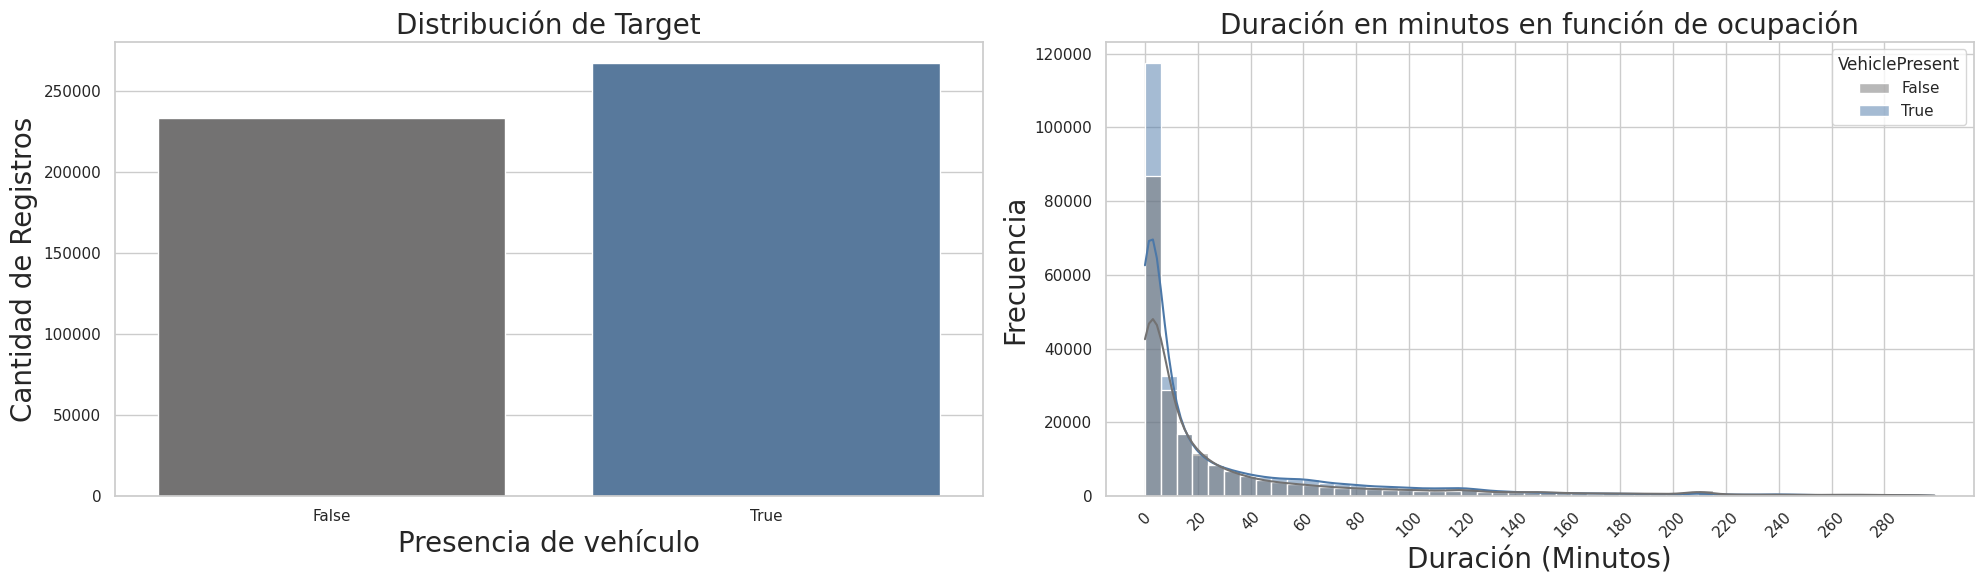

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Neutral palette without positive/negative visual bias
palette_vehicle_present = {False: "#737272", True: '#4C78A8'}
hue_order_vehicle_present = [False, True]

# Observe Target distribution to check class balance
sns.countplot(
    data=df_500k_mod,
    x='VehiclePresent',
    hue='VehiclePresent',
    hue_order=hue_order_vehicle_present,
    palette=palette_vehicle_present,
    ax=axes[0],
    legend=False
)
axes[0].set_title('Distribución de Target', fontsize=20)
axes[0].set_xlabel('Presencia de vehículo', fontsize=20)
axes[0].set_ylabel('Cantidad de Registros', fontsize=20)

# Distribution of DurationMinutes separated by target
mask_duracion = df_500k_mod['DurationMinutes'] < 300
sns.histplot(
    data=df_500k_mod[mask_duracion],
    x='DurationMinutes',
    hue='VehiclePresent',
    hue_order=hue_order_vehicle_present,
    bins=50,
    kde=True,
    palette=palette_vehicle_present,
    ax=axes[1]
)
axes[1].set_xticks(range(0, 300, 20))
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Duración en minutos en función de ocupación', fontsize=20)
axes[1].set_xlabel('Duración (Minutos)', fontsize=20)
axes[1].set_ylabel('Frecuencia', fontsize=20)


plt.tight_layout()
plt.show()

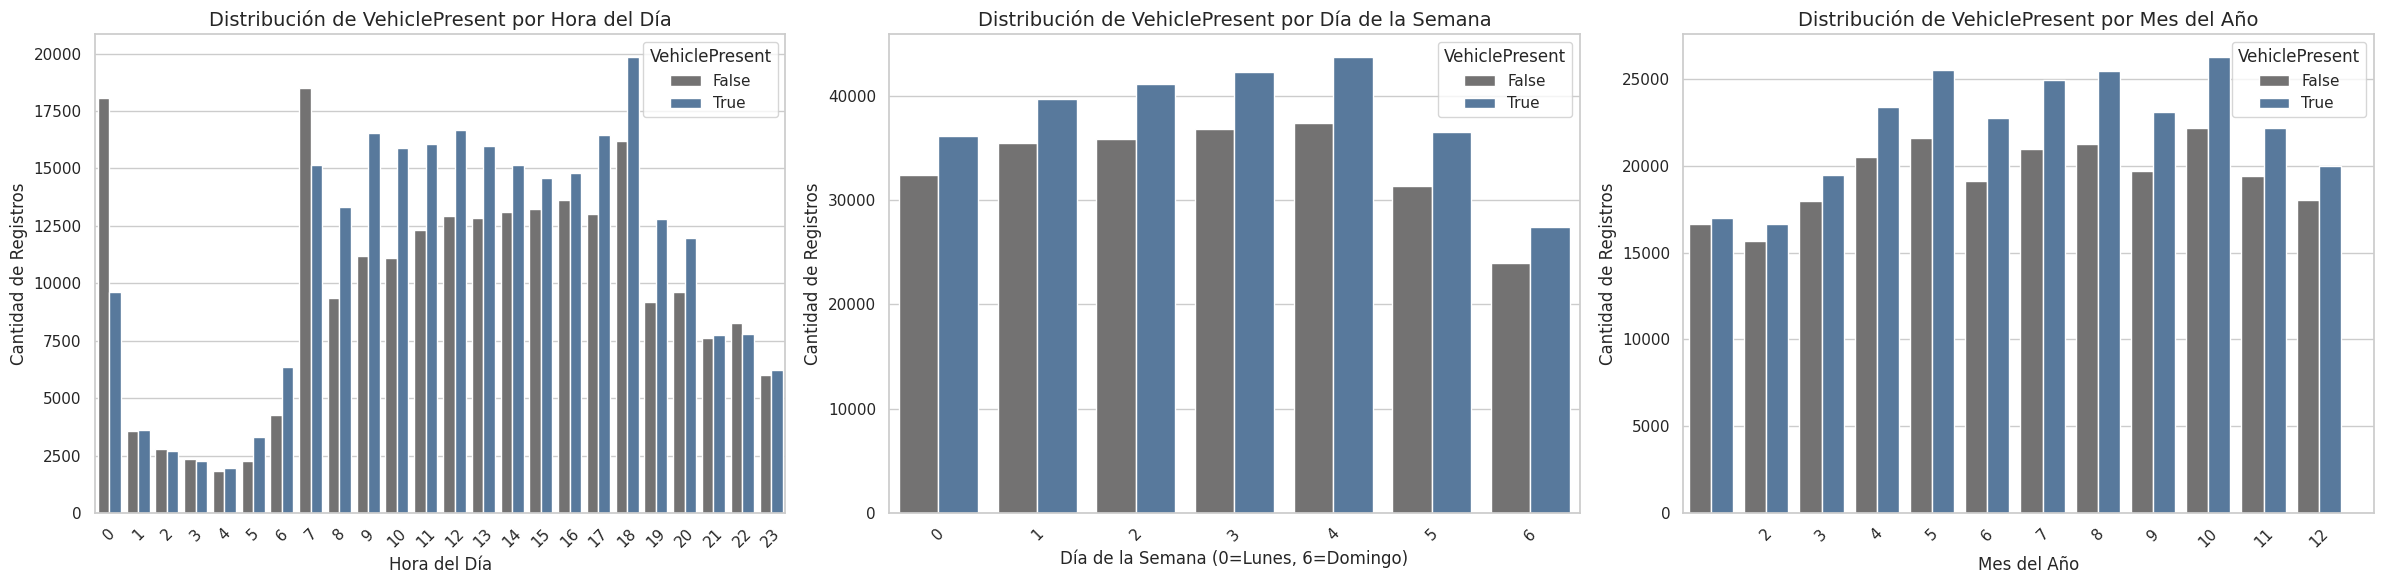

In [12]:
# Charts showing behavior by hour, day of week, and month of year
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
# Chart by hour of day
sns.countplot(
    data=df_500k_mod,
    x='Hour',
    hue='VehiclePresent',
    hue_order=hue_order_vehicle_present,
    palette=palette_vehicle_present,
    ax=axes[0]
)
axes[0].set_title('Distribución de VehiclePresent por Hora del Día', fontsize=14)
axes[0].set_xlabel('Hora del Día', fontsize=12)
axes[0].set_ylabel('Cantidad de Registros', fontsize=12)
axes[0].set_xticks(range(0, 24))
axes[0].tick_params(axis='x', rotation=45)

# Chart by day of week
sns.countplot(
    data=df_500k_mod,
    x='WeekDay',
    hue='VehiclePresent',
    hue_order=hue_order_vehicle_present,
    palette=palette_vehicle_present,
    ax=axes[1]
)
axes[1].set_title('Distribución de VehiclePresent por Día de la Semana', fontsize=14)
axes[1].set_xlabel('Día de la Semana (0=Lunes, 6=Domingo)', fontsize=12)
axes[1].set_ylabel('Cantidad de Registros', fontsize=12)
axes[1].set_xticks(range(0, 7))
axes[1].tick_params(axis='x', rotation=45)

# Chart by month of year
sns.countplot(
    data=df_500k_mod,
    x='Month',
    hue='VehiclePresent',
    hue_order=hue_order_vehicle_present,
    palette=palette_vehicle_present,
    ax=axes[2]
)
axes[2].set_title('Distribución de VehiclePresent por Mes del Año', fontsize=14)
axes[2].set_xlabel('Mes del Año', fontsize=12)
axes[2].set_ylabel('Cantidad de Registros', fontsize=12)
axes[2].set_xticks(range(1, 13))
axes[2].tick_params(axis='x', rotation=45) 
plt.tight_layout()
plt.show()

### Outliers

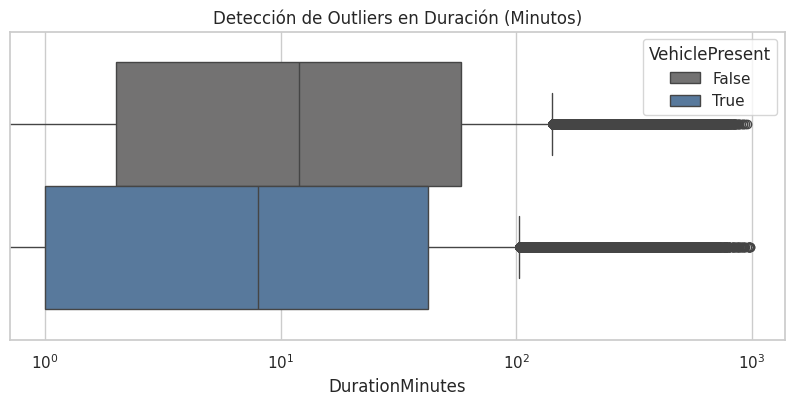

In [13]:
# DurationMinutes is the only continuous variable

palette_vehicle_present = {False: '#737272', True: '#4C78A8'}
hue_order_vehicle_present = [False, True]

plt.figure(figsize=(10, 4))
# Log-scale due to long-tailed distribution
sns.boxplot(data=df_500k_mod, x='DurationMinutes', hue='VehiclePresent', hue_order=hue_order_vehicle_present, palette=palette_vehicle_present, orient='h')
plt.xscale('log')
plt.title('Detección de Outliers en Duración (Minutos)')
plt.show()

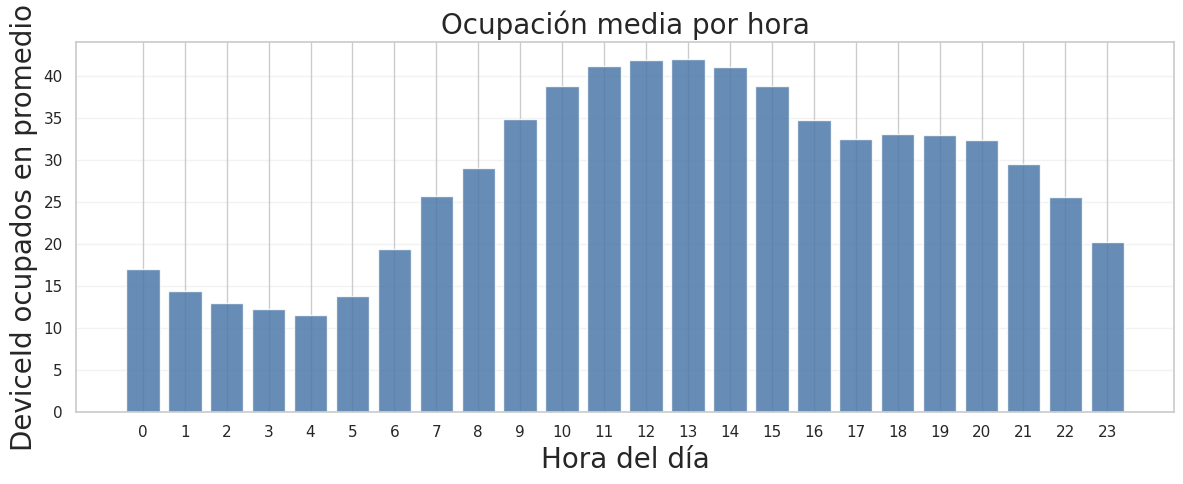

Hora pico de ocupación: 13:00
DeviceId ocupados promedio en hora pico: 42.03
Porcentaje de DeviceId ocupados en hora pico: 13.69%


In [21]:
# Average occupied DeviceIds per hour
occupied_intervals = df_500k_mod[df_500k_mod['VehiclePresent'] == True].copy()

# Round to hour to build the occupied hourly interval
occupied_intervals['start_hour'] = occupied_intervals['ArrivalTime'].dt.floor('h')
occupied_intervals['end_hour'] = occupied_intervals['DepartureTime'].dt.ceil('h')

# Ensure at least one hour per interval (avoids empty intervals)
same_hour_mask = occupied_intervals['end_hour'] <= occupied_intervals['start_hour']
occupied_intervals.loc[same_hour_mask, 'end_hour'] = occupied_intervals.loc[same_hour_mask, 'start_hour'] + pd.Timedelta(hours=1)

# Expand each interval into hours
occupied_intervals['hour_range'] = occupied_intervals.apply(
    lambda row: pd.date_range(start=row['start_hour'], end=row['end_hour'], freq='h', inclusive='left'),
    axis=1
)

occupied_by_hour = (
    occupied_intervals[['DeviceId', 'hour_range']]
    .explode('hour_range')
    .dropna(subset=['hour_range'])
)

occupied_per_timestamp = occupied_by_hour.groupby('hour_range')['DeviceId'].nunique()
# Average profile by hour of day (0-23)
mean_occupied_by_hour = (
    occupied_per_timestamp
    .groupby(occupied_per_timestamp.index.hour)
    .mean()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(12, 5))
plt.bar(mean_occupied_by_hour.index, mean_occupied_by_hour.values, color='#4C78A8', alpha=0.85)
plt.xticks(range(24))
plt.xlabel('Hora del día', fontsize=20)
plt.ylabel('DeviceId ocupados en promedio', fontsize=20)
plt.title('Ocupación media por hora', fontsize=20)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

peak_hour = int(mean_occupied_by_hour.idxmax())
peak_value = float(mean_occupied_by_hour.max())
print(f"Hora pico de ocupación: {peak_hour}:00")
print(f"DeviceId ocupados promedio en hora pico: {peak_value:.2f}")
print(f"Porcentaje de DeviceId ocupados en hora pico: {(peak_value / unique_values['DeviceId']) * 100:.2f}%")

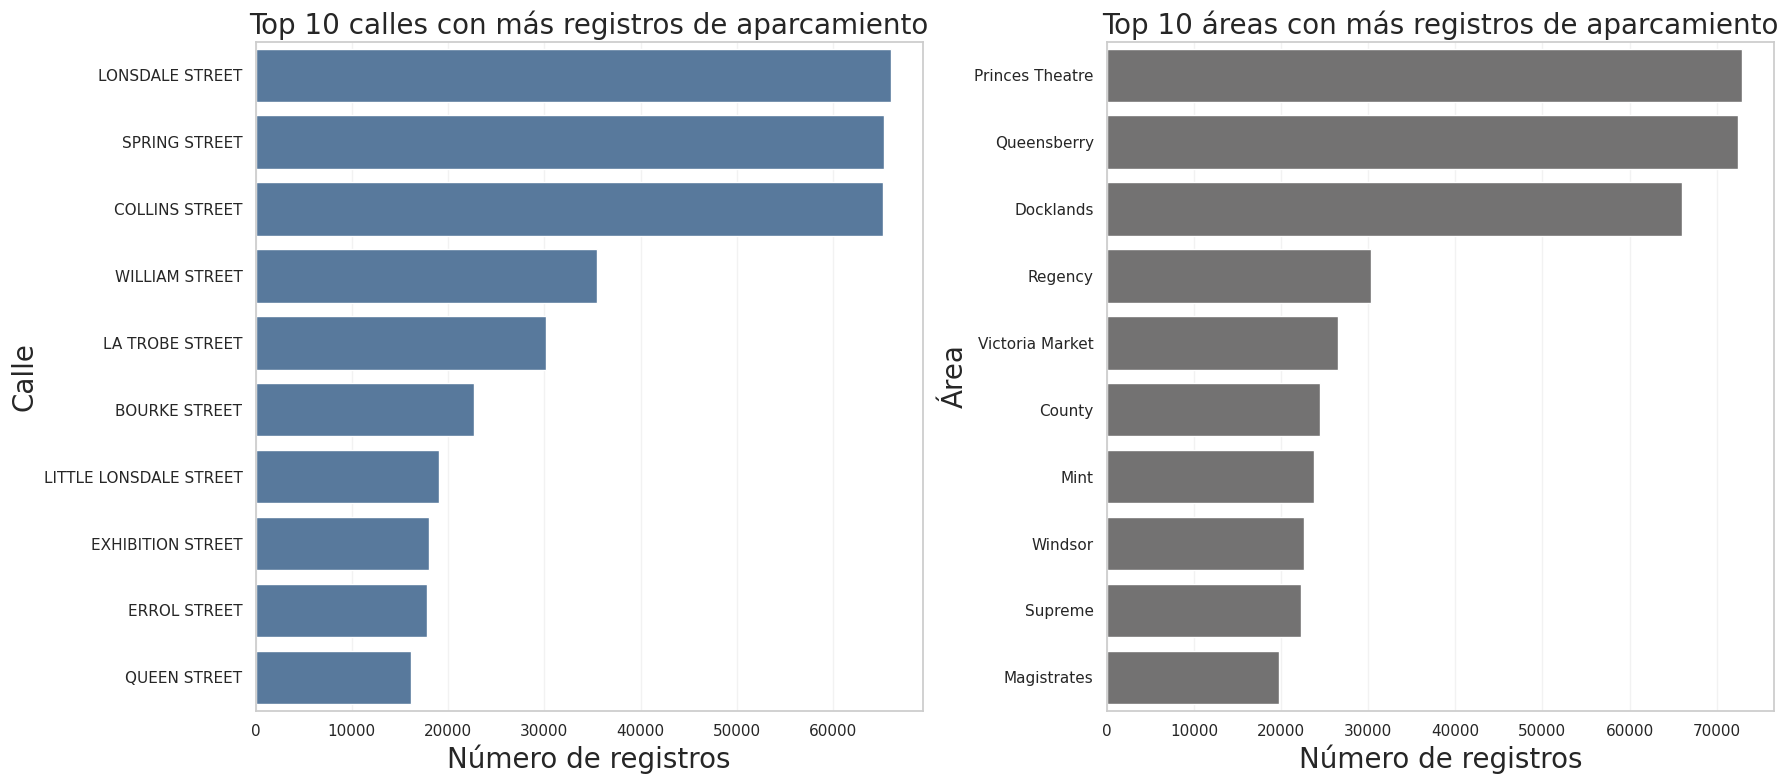

In [18]:
# Geospatial hot spots: Top 10 streets and areas with most parking records
street_col = 'StreetName'
area_col = 'AreaName'

# Build rankings (drop missing names, keep top 10, then sort for horizontal bars)
top_10_streets = (
    df_500k_mod[street_col]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values(ascending=False)
)

top_10_areas = (
    df_500k_mod[area_col]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    x=top_10_streets.values,
    y=top_10_streets.index,
    ax=axes[0],
    color='#4C78A8'
)
axes[0].set_title('Top 10 calles con más registros de aparcamiento', fontsize=20)
axes[0].set_xlabel('Número de registros', fontsize=20)
axes[0].set_ylabel('Calle', fontsize=20)
axes[0].grid(axis='x', alpha=0.25)

sns.barplot(
    x=top_10_areas.values,
    y=top_10_areas.index,
    ax=axes[1],
    color='#737272'
)
axes[1].set_title('Top 10 áreas con más registros de aparcamiento', fontsize=20)
axes[1].set_xlabel('Número de registros', fontsize=20)
axes[1].set_ylabel('Área', fontsize=20)
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# hacer dotplot en vez de los diagramas de barras anteriores
# dotplot for top 10 streets and areas with most parking records


## Exportar dataframe procesado a parquet

In [16]:
df_mod_name = os.environ.get("PARQUET_PROCESSED_EDA", "df_500k_processed.parquet")
parquet_processed_path = os.path.join(data_folder, df_mod_name)
df_500k_mod.to_parquet(parquet_processed_path, index=False)
print(f"DataFrame exportado a {parquet_processed_path}")

DataFrame exportado a ../../data/df_500k_processed.parquet


## Merge entre datos de 2019 y el dataset espacial

Se realiza el merge descartando duplicados de ubicación para obtener los sensores únicos con sus respectivas ubicaciones. Este procesamiento es fundamental para la generación del mapa de visualización de puntos de interés y la inclusión de información sobre la localización de los sensores en los modelos predictivos.

In [17]:
name_spatial = os.environ.get("PARQUET_SPATIAL_RAW_NAME", "spatial_data.parquet")
path_spatial = os.path.join(data_folder, name_spatial)
df_spatial = pd.read_parquet(path_spatial)
print("Spatial Dataset:", df_spatial.info())

<class 'pandas.DataFrame'>
RangeIndex: 23864 entries, 0 to 23863
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   roadsegmentid           23864 non-null  int64  
 1   kerbsideid              5339 non-null   str    
 2   roadsegmentdescription  23864 non-null  str    
 3   latitude                23864 non-null  float64
 4   longitude               23864 non-null  float64
 5   lastupdated             23864 non-null  object 
 6   location                23864 non-null  object 
dtypes: float64(2), int64(1), object(2), str(2)
memory usage: 2.6+ MB
Spatial Dataset: None


In [18]:
from utils.utils import find_coordinates
# Extract transversal streets from unique sensors from 2019 
cols_2019 = ['DeviceId', 'BayId', 'StreetName', 'BetweenStreet1', 'BetweenStreet2']
df_devices = df_500k_mod[cols_2019].drop_duplicates().copy()
print(f"\nSensores únicos físicos en 2019: {len(df_devices)}, shape: {df_devices.shape}")

# Select columns in spatial dataset
col_desc = 'roadsegmentdescription'
col_lat = 'latitude'
col_lon = 'longitude'

df_spatial_clean = df_spatial[[col_desc, col_lat, col_lon]].dropna(subset=[col_desc]).copy()
df_spatial_clean['desc_lower'] = df_spatial_clean[col_desc].str.lower().str.strip() # normalize text for matching

df_devices[['lat', 'lon']] = df_devices.apply(
    lambda row: find_coordinates(row, df_spatial_clean), axis=1
)

# Cleaning
matched = df_devices['lat'].notna().sum()
missing = df_devices['lat'].isna().sum()
match_rate = (matched / len(df_devices)) * 100
print(f"Matches: {matched} ({match_rate:.1f}%)")


Sensores únicos físicos en 2019: 307, shape: (307, 5)
Matches: 255 (83.1%)


In [19]:
# Build dataframe
df_sensors_geolocated = df_devices.dropna(subset=['lat', 'lon'])
print("Dimensión del dataset final de sensores geolocalizados:", df_sensors_geolocated.shape)
print(df_sensors_geolocated.head())

# Delete duplicated geolocalized pairs with the same coordinates
df_sensors_geolocated = df_sensors_geolocated.drop_duplicates(subset=['lat', 'lon'])
print(f"Dimensión del dataset final de sensores geolocalizados sin duplicados: {df_sensors_geolocated.shape}")

Dimensión del dataset final de sensores geolocalizados: (255, 7)
      DeviceId  BayId       StreetName     BetweenStreet1     BetweenStreet2  \
0        23915   1753    BOURKE STREET     RUSSELL STREET  EXHIBITION STREET   
1        23914   1532   COLLINS STREET  EXHIBITION STREET      SPRING STREET   
2        23913   1399  FLINDERS STREET       QUEEN STREET   ELIZABETH STREET   
12       23916   1728    BOURKE STREET  EXHIBITION STREET      SPRING STREET   
3213     27446   3489  FRANKLIN STREET       QUEEN STREET   ELIZABETH STREET   

            lat         lon  
0    -37.812649  144.968327  
1    -37.813710  144.972854  
2    -37.818548  144.963329  
12   -37.810486  144.972239  
3213 -37.808210  144.959893  
Dimensión del dataset final de sensores geolocalizados sin duplicados: (121, 7)


## Exportar dataframe con datos espaciales a parquet

In [20]:
filename_processed = os.environ.get("PARQUET_SPATIAL_MERGE", "df_spatial_merge.parquet")
parquet_geo_path = os.path.join(data_folder, filename_processed)
df_sensors_geolocated.to_parquet(parquet_geo_path, index=False)
print(f"DataFrame exportado a {parquet_geo_path}")

DataFrame exportado a ../../data/df_spatial_merge.parquet
